In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")
import os, sys
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec

df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\pythonProject\government_schemes.csv")
print(df)

     Scheme_ID                                 Scheme_Name  \
0        S0001              Pradhan Mantri Jan Dhan Yojana   
1        S0002          Pradhan Mantri Awas Yojana - Urban   
2        S0003         Pradhan Mantri Awas Yojana - Gramin   
3        S0004               Swachh Bharat Mission - Urban   
4        S0005              Swachh Bharat Mission - Gramin   
...        ...                                         ...   
1495     S1496   Rajiv Gandhi Dairy Development Initiative   
1496     S1497  Mahatma Gandhi Malaria Control Urja Yojana   
1497     S1498       Mukhyamantri Elderly Care Pani Yojana   
1498     S1499         Scheme for MSME Credit Sadak Yojana   
1499     S1500          Mission Agricultural Market Shakti   

                           Ministry                Category  Launch_Year  \
0               Ministry of Finance     Financial Inclusion         2014   
1               Ministry of Housing                 Housing         2015   
2     Ministry of Rural Dev

In [7]:
df

,Scheme_ID,Scheme_Name,Ministry,Category,Launch_Year,Target_Beneficiaries,Budget_Allocated_Crore,Budget_Utilized_Crore,States_Covered,Beneficiaries_Reached_Lakh,...,Application_Mode,Success_Rate_%,Grievances_Filed,Grievances_Resolved,Scheme_Duration_Years,Annual_Report_Available,Website_Available,PM_Flagship,Nodal_Agency,Remarks
0,S0001,Pradhan Mantri Jan Dhan Yojana,Ministry of Finance,Financial Inclusion,2014,All Citizens,10000.0,9800.0,All States,50.09,...,Online/Offline,98.0,12000.0,11500.0,Ongoing,Yes,Yes,Yes,Department of Financial Services,NaN
1,S0002,Pradhan Mantri Awas Yojana - Urban,Ministry of Housing,Housing,2015,Urban Poor,60000.0,48500.0,All States,120.00,...,Online,80.8,45000.0,38000.0,2022,Yes,Yes,Yes,HUDCO,NaN
2,S0003,Pradhan Mantri Awas Yojana - Gramin,Ministry of Rural Development,Housing,2016,Rural Poor,130000.0,NaN,All States,250.00,...,Offline,85.0,NaN,32000.0,2024,Yes,Yes,Yes,DRDA,Missing budget utilization data
3,S0004,Swachh Bharat Mission - Urban,Ministry of Housing,Sanitation,2014,Urban Households,62009.0,59000.0,All States,180.00,...,Online/Offline,95.2,8900.0,8100.0,2024,Yes,Yes,Yes,MoHUA,NaN
4,S0005,Swachh Bharat Mission - Gramin,Ministry of Jal Shakti,Sanitation,2014,Rural Households,134000.0,130000.0,All States,600.00,...,Offline,96.8,5200.0,5000.0,2019,Yes,Yes,Yes,DDWS,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,S1496,Rajiv Gandhi Dairy Development Initiative,Ministry of Social Justice,Digital Infrastructure,1956,Small Entrepreneurs,497601.0,164504.0,All States,7278.00,...,Online,44.3,149058.0,99469.0,1984,Yes,Yes,No,REC,Merged with another scheme
1496,S1497,Mahatma Gandhi Malaria Control Urja Yojana,Ministry of Defence,Innovation,2001,Minorities,NaN,NaN,16,5314.53,...,Multiple,98.4,352034.0,347536.0,5,Yes,No,No,FCI,NaN
1497,S1498,Mukhyamantri Elderly Care Pani Yojana,Ministry of Finance,Child Development,2000,Students,141860.0,55294.0,All States,46.12,...,Online/Offline,34.1,163273.0,150767.0,10,Yes,Yes,No,WCD,Merged with another scheme
1498,S1499,Scheme for MSME Credit Sadak Yojana,Ministry of Education,Scholarships,2003,Women,327718.0,162079.0,All States,529.79,...,Multiple,63.3,493280.0,396067.0,15,Yes,Yes,Yes,DFPD,NaN


In [22]:
df.describe()

,Launch_Year,Budget_Allocated_Crore,Budget_Utilized_Crore,Beneficiaries_Reached_Lakh,Success_Rate_%,Grievances_Filed,Grievances_Resolved,Budget_Utilization_%,Grievance_Resolution_%
count,1500.000000,1377.000000,1222.000000,1265.000000,1409.000000,1499.000000,1419.000000,1222.000000,1418.000000
mean,1988.433333,243515.070443,163653.662848,7682.663858,65.307133,251113.008005,201656.252995,67.391321,80.183578
std,21.271653,144065.413470,114465.059490,4314.647307,20.479611,143087.286770,119562.314345,21.380447,11.594465
min,1952.000000,85.000000,59.000000,19.340000,30.000000,397.000000,264.000000,30.057540,60.000322
25%,1970.000000,123087.000000,69558.750000,3999.140000,47.400000,131127.000000,102799.000000,48.889685,70.245594
50%,1990.000000,235958.000000,147782.500000,7815.770000,64.800000,250083.000000,199239.000000,67.768317,80.411554
75%,2006.000000,367675.000000,236210.500000,11436.980000,83.700000,367713.000000,292125.000000,85.108332,90.363092
max,2024.000000,499455.000000,512055.000000,14958.620000,100.000000,499508.000000,485924.000000,104.993896,99.874004


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Scheme_ID                   1500 non-null   str    
 1   Scheme_Name                 1500 non-null   str    
 2   Ministry                    1500 non-null   str    
 3   Category                    1500 non-null   str    
 4   Launch_Year                 1500 non-null   int64  
 5   Target_Beneficiaries        1500 non-null   str    
 6   Budget_Allocated_Crore      1377 non-null   float64
 7   Budget_Utilized_Crore       1222 non-null   float64
 8   States_Covered              1500 non-null   str    
 9   Beneficiaries_Reached_Lakh  1265 non-null   float64
 10  Status                      1500 non-null   str    
 11  Mode                        1500 non-null   str    
 12  Gender_Focus                1500 non-null   str    
 13  Age_Group                   1500 non-null   

In [24]:
df.head()

,Scheme_ID,Scheme_Name,Ministry,Category,Launch_Year,Target_Beneficiaries,Budget_Allocated_Crore,Budget_Utilized_Crore,States_Covered,Beneficiaries_Reached_Lakh,...,Grievances_Resolved,Scheme_Duration_Years,Annual_Report_Available,Website_Available,PM_Flagship,Nodal_Agency,Remarks,Budget_Utilization_%,Grievance_Resolution_%,Decade
0,S0001,Pradhan Mantri Jan Dhan Yojana,Ministry of Finance,Financial Inclusion,2014,All Citizens,10000.0,9800.0,All States,50.09,...,11500.0,Ongoing,Yes,Yes,Yes,Department of Financial Services,NaN,98.000000,95.833333,2010s
1,S0002,Pradhan Mantri Awas Yojana - Urban,Ministry of Housing,Housing,2015,Urban Poor,60000.0,48500.0,All States,120.00,...,38000.0,2022,Yes,Yes,Yes,HUDCO,NaN,80.833333,84.444444,2010s
2,S0003,Pradhan Mantri Awas Yojana - Gramin,Ministry of Rural Development,Housing,2016,Rural Poor,130000.0,NaN,All States,250.00,...,32000.0,2024,Yes,Yes,Yes,DRDA,Missing budget utilization data,NaN,NaN,2010s
3,S0004,Swachh Bharat Mission - Urban,Ministry of Housing,Sanitation,2014,Urban Households,62009.0,59000.0,All States,180.00,...,8100.0,2024,Yes,Yes,Yes,MoHUA,NaN,95.147479,91.011236,2010s
4,S0005,Swachh Bharat Mission - Gramin,Ministry of Jal Shakti,Sanitation,2014,Rural Households,134000.0,130000.0,All States,600.00,...,5000.0,2019,Yes,Yes,Yes,DDWS,NaN,97.014925,96.153846,2010s


In [25]:
df.tail()

,Scheme_ID,Scheme_Name,Ministry,Category,Launch_Year,Target_Beneficiaries,Budget_Allocated_Crore,Budget_Utilized_Crore,States_Covered,Beneficiaries_Reached_Lakh,...,Grievances_Resolved,Scheme_Duration_Years,Annual_Report_Available,Website_Available,PM_Flagship,Nodal_Agency,Remarks,Budget_Utilization_%,Grievance_Resolution_%,Decade
1495,S1496,Rajiv Gandhi Dairy Development Initiative,Ministry of Social Justice,Digital Infrastructure,1956,Small Entrepreneurs,497601.0,164504.0,All States,7278.00,...,99469.0,1984,Yes,Yes,No,REC,Merged with another scheme,33.059419,66.731742,1950s
1496,S1497,Mahatma Gandhi Malaria Control Urja Yojana,Ministry of Defence,Innovation,2001,Minorities,NaN,NaN,16,5314.53,...,347536.0,5,Yes,No,No,FCI,NaN,NaN,98.722283,2000s
1497,S1498,Mukhyamantri Elderly Care Pani Yojana,Ministry of Finance,Child Development,2000,Students,141860.0,55294.0,All States,46.12,...,150767.0,10,Yes,Yes,No,WCD,Merged with another scheme,38.977866,92.340436,2000s
1498,S1499,Scheme for MSME Credit Sadak Yojana,Ministry of Education,Scholarships,2003,Women,327718.0,162079.0,All States,529.79,...,396067.0,15,Yes,Yes,Yes,DFPD,NaN,49.456850,80.292532,2000s
1499,S1500,Mission Agricultural Market Shakti,Ministry of Rural Development,Governance,2021,Artisans,311245.0,NaN,All States,12939.90,...,298078.0,2025,Yes,No,No,NDDB,NaN,NaN,64.029815,2020s


In [26]:
df.shape

(1500, 27)

In [28]:
df.columns

Index(['Scheme_ID', 'Scheme_Name', 'Ministry', 'Category', 'Launch_Year',
       'Target_Beneficiaries', 'Budget_Allocated_Crore',
       'Budget_Utilized_Crore', 'States_Covered', 'Beneficiaries_Reached_Lakh',
       'Status', 'Mode', 'Gender_Focus', 'Age_Group', 'Application_Mode',
       'Success_Rate_%', 'Grievances_Filed', 'Grievances_Resolved',
       'Scheme_Duration_Years', 'Annual_Report_Available', 'Website_Available',
       'PM_Flagship', 'Nodal_Agency', 'Remarks', 'Budget_Utilization_%',
       'Grievance_Resolution_%', 'Decade'],
      dtype='str')

In [29]:
df.isnull().sum()

Scheme_ID                       0
Scheme_Name                     0
Ministry                        0
Category                        0
Launch_Year                     0
Target_Beneficiaries            0
Budget_Allocated_Crore        123
Budget_Utilized_Crore         278
States_Covered                  0
Beneficiaries_Reached_Lakh    235
Status                          0
Mode                            0
Gender_Focus                    0
Age_Group                       0
Application_Mode              311
Success_Rate_%                 91
Grievances_Filed                1
Grievances_Resolved            81
Scheme_Duration_Years           0
Annual_Report_Available         0
Website_Available               0
PM_Flagship                     0
Nodal_Agency                    0
Remarks                       383
Budget_Utilization_%          278
Grievance_Resolution_%         82
Decade                          0
dtype: int64

In [33]:
df = df.dropna()

In [34]:
df.isnull().sum()

Scheme_ID                     0
Scheme_Name                   0
Ministry                      0
Category                      0
Launch_Year                   0
Target_Beneficiaries          0
Budget_Allocated_Crore        0
Budget_Utilized_Crore         0
States_Covered                0
Beneficiaries_Reached_Lakh    0
Status                        0
Mode                          0
Gender_Focus                  0
Age_Group                     0
Application_Mode              0
Success_Rate_%                0
Grievances_Filed              0
Grievances_Resolved           0
Scheme_Duration_Years         0
Annual_Report_Available       0
Website_Available             0
PM_Flagship                   0
Nodal_Agency                  0
Remarks                       0
Budget_Utilization_%          0
Grievance_Resolution_%        0
Decade                        0
dtype: int64

In [35]:
for col in ["Budget_Allocated_Crore","Budget_Utilized_Crore",
            "Beneficiaries_Reached_Lakh","Success_Rate_%",
            "Grievances_Filed","Grievances_Resolved","Launch_Year"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Budget_Utilization_%"]   = (df["Budget_Utilized_Crore"] /
                                  df["Budget_Allocated_Crore"]*100).clip(0,120)
df["Grievance_Resolution_%"] = (df["Grievances_Resolved"] /
                                  df["Grievances_Filed"]*100).clip(0,100)
df["Decade"] = ((df["Launch_Year"]//10)*10).astype("Int64").astype(str)+"s"


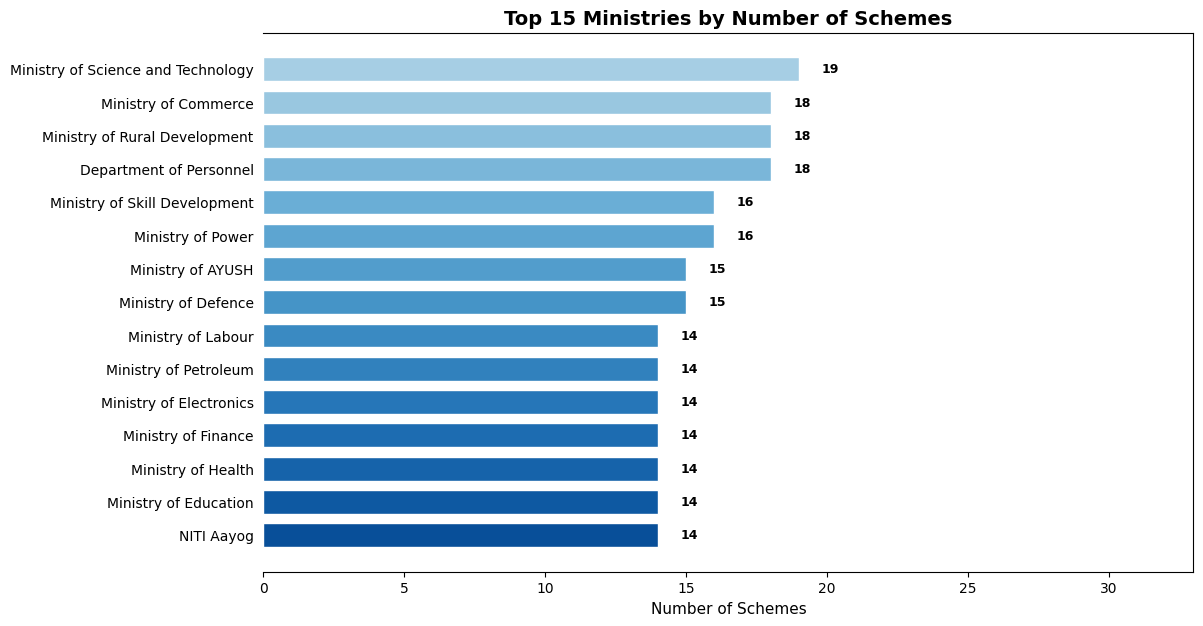

In [36]:
fig, ax = plt.subplots(figsize=(12,7))
top_min = df["Ministry"].value_counts().head(15)
cols    = cm.Blues(np.linspace(0.35,0.88,15))[::-1]
bars    = ax.barh(top_min.index[::-1], top_min.values[::-1],
                  color=cols, edgecolor="white", height=0.72)
for bar, val in zip(bars, top_min.values[::-1]):
    ax.text(bar.get_width()+0.8, bar.get_y()+bar.get_height()/2,
            str(val), va="center", fontsize=9, fontweight="bold")
ax.set_xlabel("Number of Schemes", fontsize=11)
ax.set_title("Top 15 Ministries by Number of Schemes", fontsize=14, fontweight="bold")
ax.set_xlim(0, top_min.max()+14)
ax.spines["left"].set_visible(False); ax.tick_params(left=False)


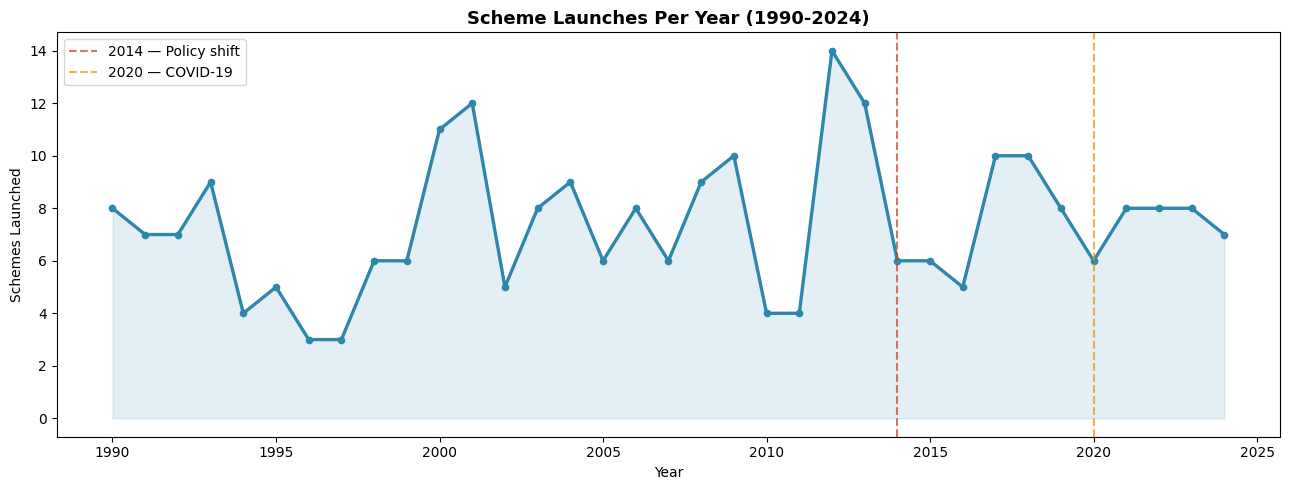

In [37]:
fig, ax = plt.subplots(figsize=(13,5))
yr = df[df["Launch_Year"]>=1990]["Launch_Year"].value_counts().sort_index()
ax.plot(yr.index, yr.values, color="#2E86AB", lw=2.4, marker="o", markersize=4.5)
ax.fill_between(yr.index, yr.values, alpha=0.13, color="#2E86AB")
ax.axvline(2014, color="#C73E1D", ls="--", alpha=0.7, label="2014 — Policy shift")
ax.axvline(2020, color="#F18F01", ls="--", alpha=0.7, label="2020 — COVID-19")
ax.set_xlabel("Year"); ax.set_ylabel("Schemes Launched")
ax.set_title("Scheme Launches Per Year (1990-2024)", fontsize=13, fontweight="bold")
ax.legend(); fig.tight_layout();

Text(0.5, 1.0, 'Exploded Pie: Gender Focus')

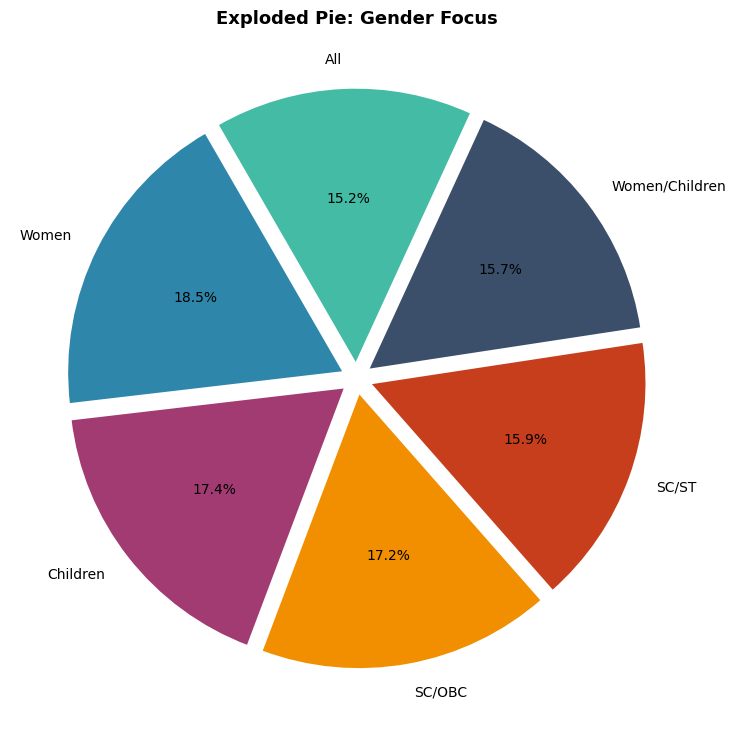

In [38]:
PAL  = ["#2E86AB","#A23B72","#F18F01","#C73E1D","#3B4F6B",
        "#44BBA4","#E94F37","#6A4C93","#F5A623","#1B998B"]

fig, ax = plt.subplots(figsize=(9,9))
gf      = df["Gender_Focus"].value_counts()
ax.pie(gf.values, labels=gf.index, autopct="%1.1f%%",
       explode=[0.05]*len(gf), colors=PAL[:len(gf)], startangle=120,
       wedgeprops={"edgecolor":"white","linewidth":1.8})
ax.set_title("Exploded Pie: Gender Focus", fontsize=13, fontweight="bold")


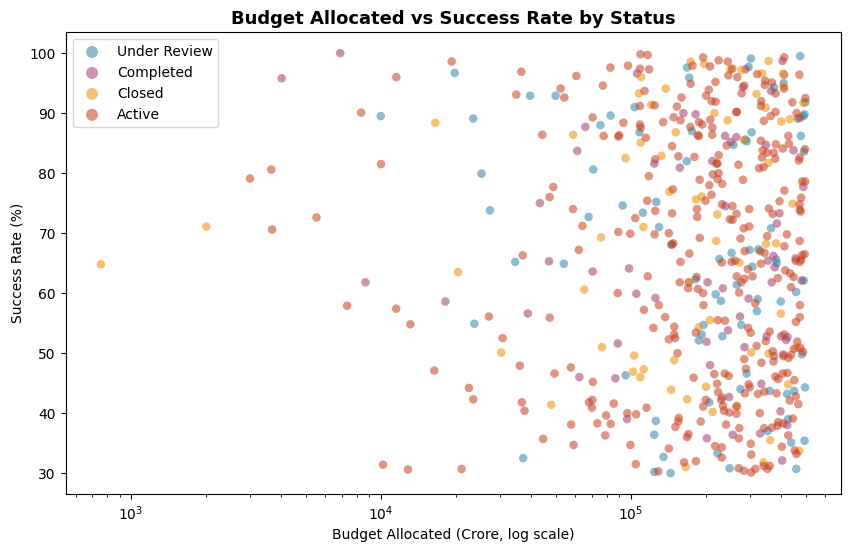

In [39]:
fig, ax = plt.subplots(figsize=(10,6))
for s,c in zip(df["Status"].unique(), PAL):
    sub = df[(df["Status"]==s) & df["Budget_Allocated_Crore"].notna() & df["Success_Rate_%"].notna()]
    ax.scatter(sub["Budget_Allocated_Crore"], sub["Success_Rate_%"],
               alpha=0.55, s=38, color=c, label=s, edgecolors="none")
ax.set_xscale("log")
ax.set_xlabel("Budget Allocated (Crore, log scale)"); ax.set_ylabel("Success Rate (%)")
ax.set_title("Budget Allocated vs Success Rate by Status", fontsize=13, fontweight="bold")
ax.legend(markerscale=1.4)

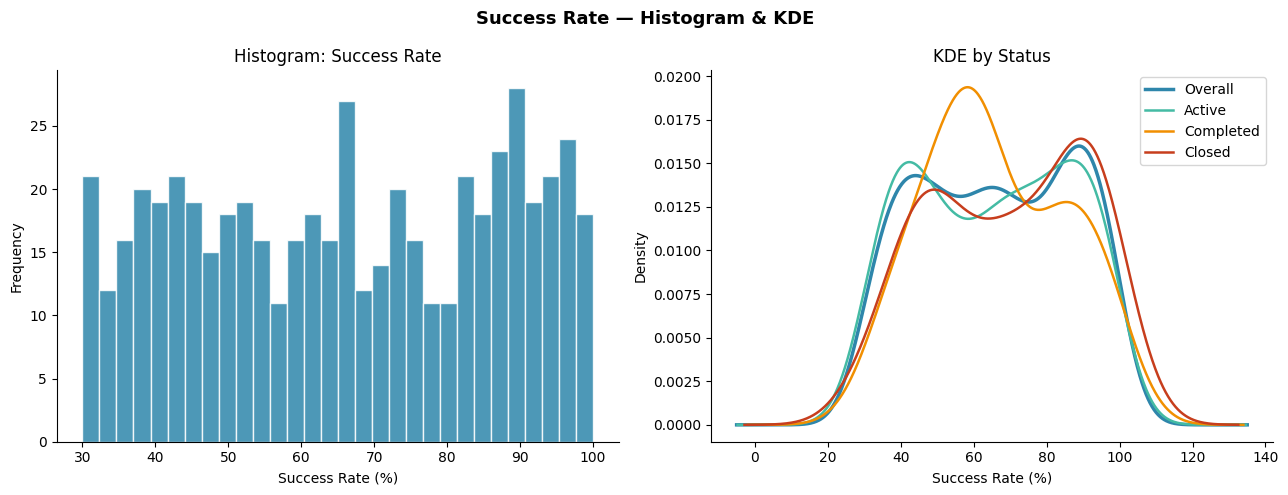

In [40]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
df["Success_Rate_%"].dropna().plot.hist(bins=30, ax=axes[0], color="#2E86AB", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Success Rate (%)"); axes[0].set_title("Histogram: Success Rate")
df["Success_Rate_%"].dropna().plot.kde(ax=axes[1], color="#2E86AB", lw=2.5, label="Overall")
for s,c in zip(["Active","Completed","Closed"],["#44BBA4","#F18F01","#C73E1D"]):
    d = df[df["Status"]==s]["Success_Rate_%"].dropna()
    if len(d)>5: d.plot.kde(ax=axes[1], color=c, lw=1.8, label=s)
axes[1].set_xlabel("Success Rate (%)"); axes[1].set_title("KDE by Status"); axes[1].legend()
for a in axes: a.spines[["top","right"]].set_visible(False)
fig.suptitle("Success Rate — Histogram & KDE", fontsize=13, fontweight="bold")
fig.tight_layout();

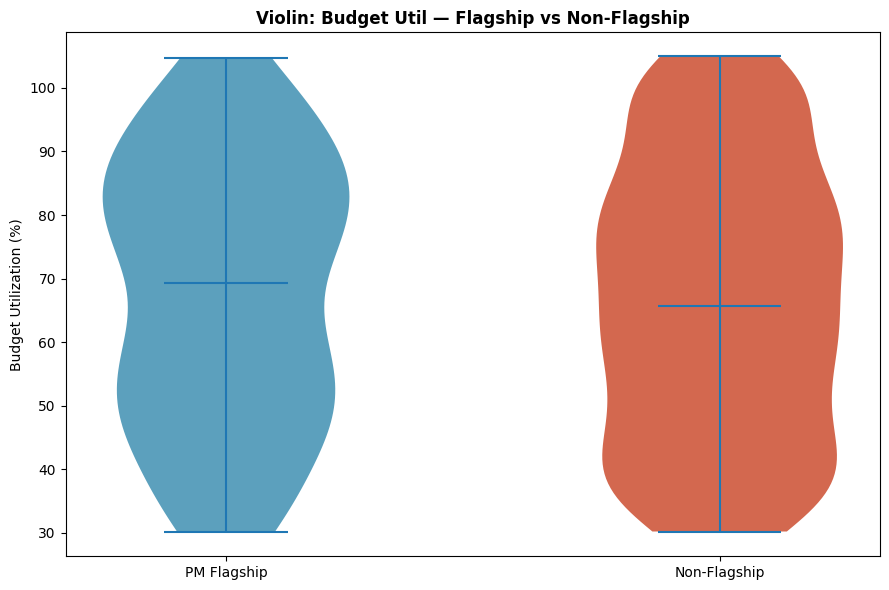

In [41]:
fig, ax = plt.subplots(figsize=(9,6))
flag_data = [df[df["PM_Flagship"]=="Yes"]["Budget_Utilization_%"].dropna().clip(0,120).values,
             df[df["PM_Flagship"]=="No"]["Budget_Utilization_%"].dropna().clip(0,120).values]
vp = ax.violinplot(flag_data, showmedians=True)
for pc,c in zip(vp["bodies"],["#2E86AB","#C73E1D"]): pc.set_facecolor(c); pc.set_alpha(0.78)
ax.set_xticks([1,2]); ax.set_xticklabels(["PM Flagship","Non-Flagship"])
ax.set_ylabel("Budget Utilization (%)")
ax.set_title("Violin: Budget Util — Flagship vs Non-Flagship", fontsize=12, fontweight="bold")
fig.tight_layout();

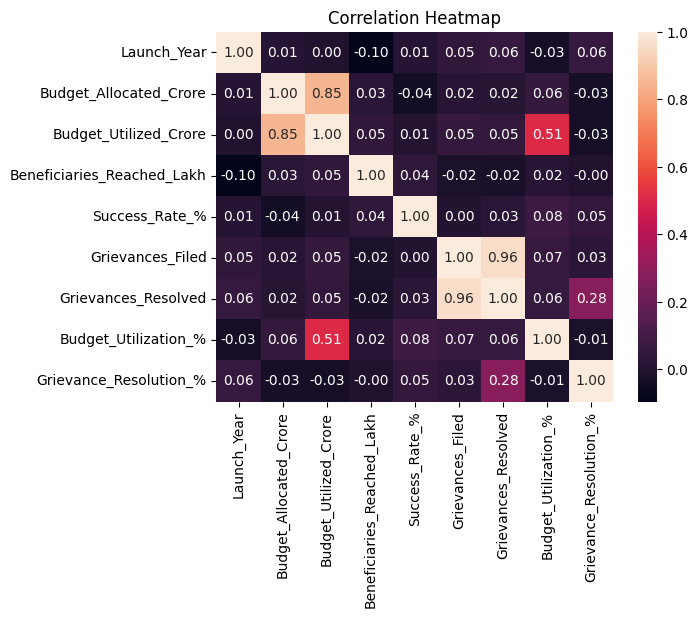

In [44]:
plt.figure()
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

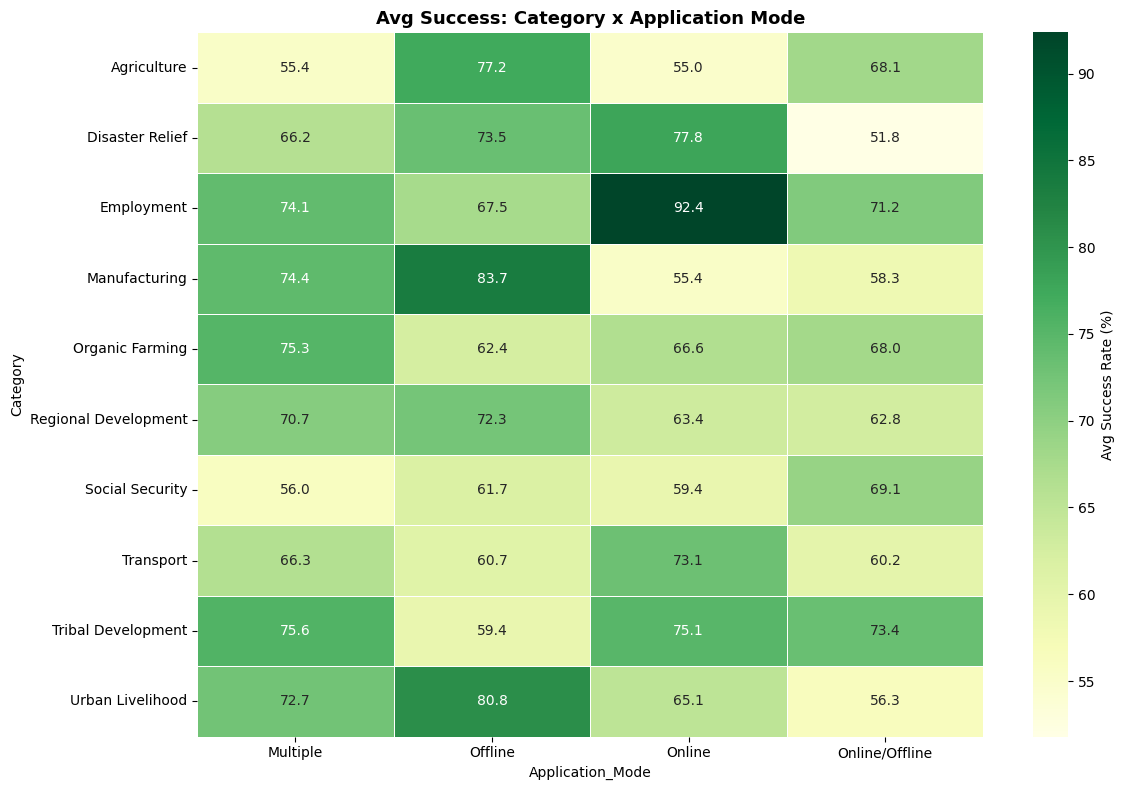

In [42]:
fig, ax = plt.subplots(figsize=(12,8))
top_cat = df["Category"].value_counts().head(10).index
pvt2    = df[df["Category"].isin(top_cat)].pivot_table(
              index="Category", columns="Application_Mode",
              values="Success_Rate_%", aggfunc="mean")
sns.heatmap(pvt2, annot=True, fmt=".1f", cmap="YlGn", ax=ax,
            linewidths=0.5, cbar_kws={"label":"Avg Success Rate (%)"})
ax.set_title("Avg Success: Category x Application Mode", fontsize=13, fontweight="bold")
fig.tight_layout();

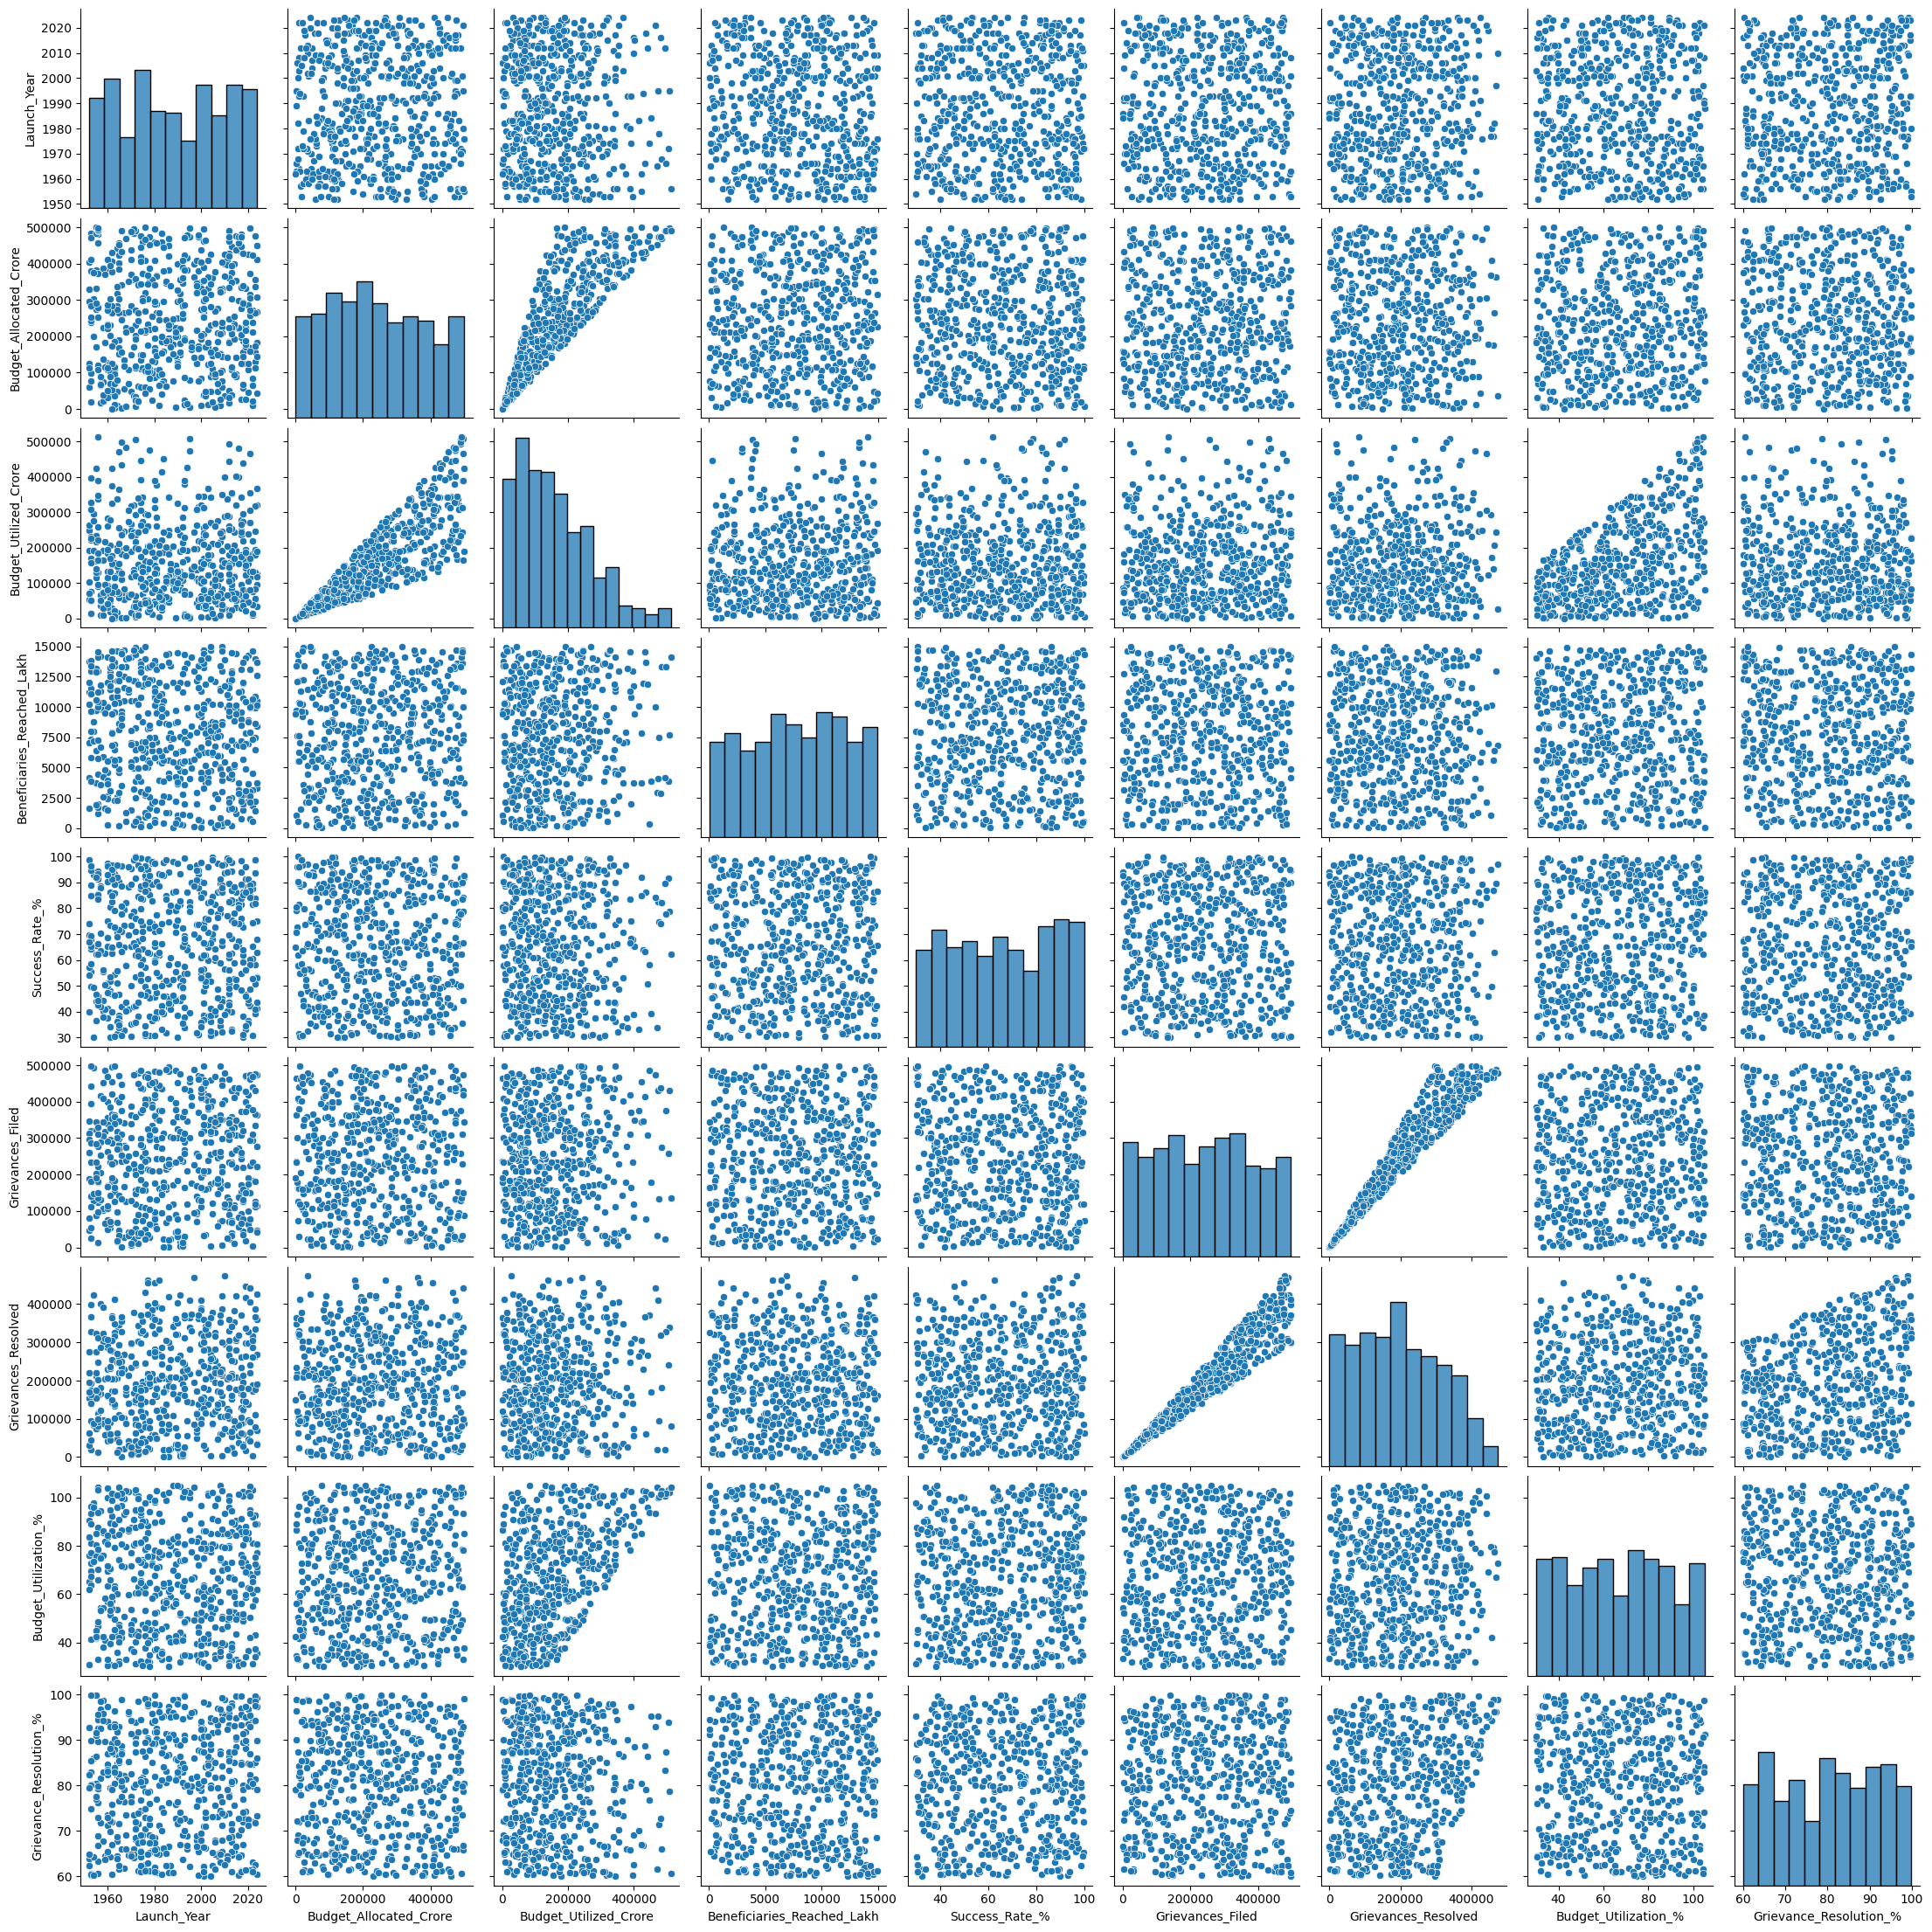

In [45]:
sns.pairplot(df)
plt.show()

-- Section 14: Pair Plot --


Text(0.5, 1.01, 'Pair Plot: Key Numeric Features by Status')

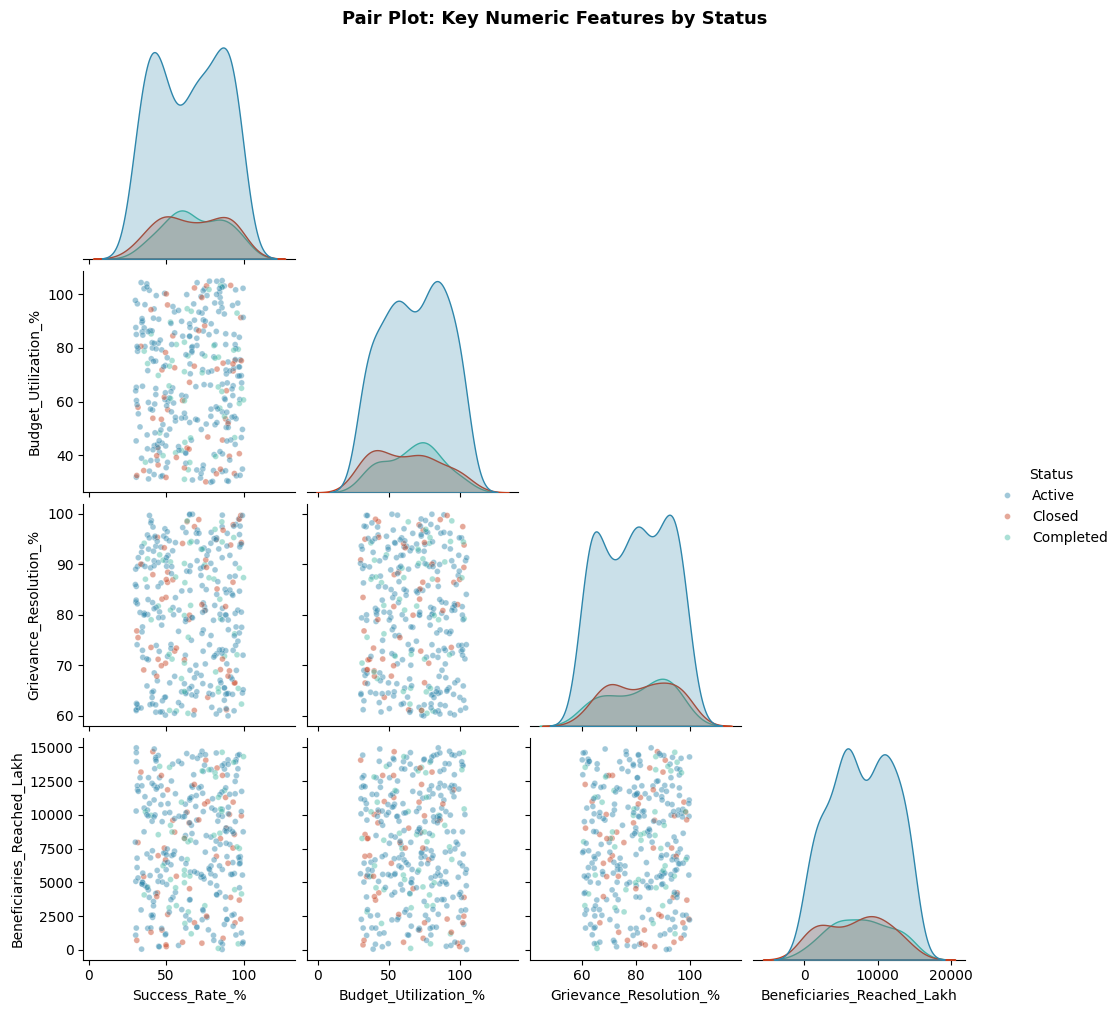

In [43]:
print("-- Section 14: Pair Plot --")

pair_cols = ["Success_Rate_%","Budget_Utilization_%","Grievance_Resolution_%",
             "Beneficiaries_Reached_Lakh","Status"]
pair_df   = df[pair_cols].dropna().sample(min(400,len(df)), random_state=42)
pair_df   = pair_df[pair_df["Status"].isin(["Active","Completed","Closed"])]
g = sns.pairplot(pair_df, hue="Status",
                 palette={"Active":"#2E86AB","Completed":"#44BBA4","Closed":"#C73E1D"},
                 plot_kws={"alpha":0.45,"s":18}, diag_kind="kde", corner=True)
g.fig.suptitle("Pair Plot: Key Numeric Features by Status", y=1.01, fontsize=13, fontweight="bold")

In [46]:

top_success = df.sort_values(by='Success_Rate_%', ascending=False).head(5)
print(top_success[['Scheme_Name', 'Success_Rate_%']])

                                     Scheme_Name  Success_Rate_%
683      State Persons with Disability Karyakram           100.0
938                 State Cold Chain Bima Yojana            99.8
896       Digital Fluorosis Control Sadak Yojana            99.7
647   Indira Gandhi Digital Literacy Pani Yojana            99.5
1033             Central Urban Housing Jan Vikas            99.3


In [47]:
print("Mean:", df['Success_Rate_%'].mean())
print("Median:", df['Success_Rate_%'].median())
print("Mode:", df['Success_Rate_%'].mode())

Mean: 66.04240740740741
Median: 65.65
Mode: 0    61.8
Name: Success_Rate_%, dtype: float64


In [48]:
from scipy.stats import ttest_ind

group1 = df[df['Gender_Focus'] == 'Male']['Success_Rate_%']
group2 = df[df['Gender_Focus'] == 'Female']['Success_Rate_%']

t_stat, p_val = ttest_ind(group1, group2)
print("T-test:", t_stat, p_val)

T-test: nan nan


In [49]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Category'], df['Status'])
chi2, p, dof, exp = chi2_contingency(table)

print("Chi-square:", chi2, "P-value:", p)

Chi-square: 117.85992272256246 P-value: 0.5381828387159212


In [58]:
# ==============================
# 1. IMPORTS
# ==============================


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


# ==============================
# 2. LOAD DATA
# ==============================


# ==============================
# 3. FEATURE ENGINEERING (FIXED)
# ==============================
df["Budget_Utilization_Pct"] = (
    df["Budget_Utilized_Crore"] /
    df["Budget_Allocated_Crore"].replace(0, np.nan) * 100
).clip(0, 120)

df["Grievance_Resolution_Pct"] = (
    df["Grievances_Resolved"] /
    df["Grievances_Filed"].replace(0, np.nan) * 100
).clip(0, 100)

df["Scheme_Age"] = 2026 - df["Launch_Year"]
df["Log_Budget"] = np.log1p(df["Budget_Allocated_Crore"].fillna(0))
df["Log_Beneficiaries"] = np.log1p(df["Beneficiaries_Reached_Lakh"].fillna(0))

df["Has_Website"] = (df["Website_Available"] == "Yes").astype(int)
df["Has_Report"] = (df["Annual_Report_Available"] == "Yes").astype(int)
df["Is_Flagship"] = (df["PM_Flagship"] == "Yes").astype(int)


# ==============================
# 4. LABEL ENCODING (FIXED)
# ==============================
encoders = {}

cat_cols = ["Ministry","Category","Gender_Focus","Application_Mode","Mode",
            "Target_Beneficiaries","Age_Group","Status"]

for col in cat_cols:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    encoders[col] = le


# ==============================
# 5. FEATURES & TARGETS
# ==============================
FEATURE_COLS = [
    "Launch_Year","Scheme_Age","Log_Budget","Log_Beneficiaries",
    "Budget_Utilization_Pct","Grievance_Resolution_Pct",
    "Grievances_Filed","Has_Website","Has_Report","Is_Flagship",
    "Ministry_enc","Category_enc","Gender_Focus_enc",
    "Application_Mode_enc","Mode_enc"
]

# Regression
df_reg = df[FEATURE_COLS + ["Success_Rate_%"]].dropna()
X_reg = df_reg[FEATURE_COLS].values
y_reg = df_reg["Success_Rate_%"].values

# Classification
df_clf = df[FEATURE_COLS + ["Status"]].dropna()
X_clf = df_clf[FEATURE_COLS].values
y_clf = df_clf["Status"].values

le_target = LabelEncoder()
y_clf_enc = le_target.fit_transform(y_clf)


# ==============================
# 6. SCALING
# ==============================
X_reg = np.nan_to_num(X_reg)
X_clf = np.nan_to_num(X_clf)

scaler = StandardScaler()
X_reg_s = scaler.fit_transform(X_reg)
X_clf_s = scaler.fit_transform(X_clf)


# ==============================
# 7. TRAIN TEST SPLIT
# ==============================
X_tr, X_te, y_tr, y_te = train_test_split(X_reg_s, y_reg, test_size=0.2, random_state=42)

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_clf_s, y_clf_enc, test_size=0.2, random_state=42, stratify=y_clf_enc
)


# ==============================
# 8. LINEAR REGRESSION
# ==============================
lr = LinearRegression()
lr.fit(X_tr, y_tr)

y_pred_lr = lr.predict(X_te)

print("\n===== LINEAR REGRESSION =====")
print("RMSE:", np.sqrt(mean_squared_error(y_te, y_pred_lr)))
print("MAE:", mean_absolute_error(y_te, y_pred_lr))
print("R2:", r2_score(y_te, y_pred_lr))


# ==============================
# 9. RANDOM FOREST REGRESSOR
# ==============================
rf_reg = RandomForestRegressor(n_estimators=150, max_depth=8, random_state=42)
rf_reg.fit(X_tr, y_tr)

y_pred_rf = rf_reg.predict(X_te)

print("\n===== RANDOM FOREST REGRESSOR =====")
print("RMSE:", np.sqrt(mean_squared_error(y_te, y_pred_rf)))
print("MAE:", mean_absolute_error(y_te, y_pred_rf))
print("R2:", r2_score(y_te, y_pred_rf))


# ==============================
# 10. RANDOM FOREST CLASSIFIER
# ==============================
rf_clf = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42)
rf_clf.fit(Xc_tr, yc_tr)

yc_pred = rf_clf.predict(Xc_te)

print("\n===== RANDOM FOREST CLASSIFIER =====")
print("Accuracy:", accuracy_score(yc_te, yc_pred))
print("F1 Score:", f1_score(yc_te, yc_pred, average="weighted"))

print("\nClassification Report:")
print(classification_report(yc_te, yc_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(yc_te, yc_pred))


===== LINEAR REGRESSION =====
RMSE: 21.901453572079564
MAE: 18.515154729727037
R2: -0.05877341740864073

===== RANDOM FOREST REGRESSOR =====
RMSE: 22.35414485586108
MAE: 19.03117080722903
R2: -0.10299430958892297

===== RANDOM FOREST CLASSIFIER =====
Accuracy: 0.6018518518518519
F1 Score: 0.4522586169985014

Classification Report:
              precision    recall  f1-score   support

           0       0.60      1.00      0.75        65
           1       0.00      0.00      0.00        13
           2       0.00      0.00      0.00        13
           3       0.00      0.00      0.00        17

    accuracy                           0.60       108
   macro avg       0.15      0.25      0.19       108
weighted avg       0.36      0.60      0.45       108


Confusion Matrix:
[[65  0  0  0]
 [13  0  0  0]
 [13  0  0  0]
 [17  0  0  0]]
